In [8]:
!pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib

from getpass import getpass
hf_token = getpass("HF token daalo: ")

import duckdb
con = duckdb.connect()

# SAHI syntax - dataset card se
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

HF token daalo: ··········


In [11]:
files = con.execute(f"""
    SELECT * FROM glob('{rel}/fact_content_daily_performance/**')
""").df()

import pandas as pd
pd.set_option('display.max_colwidth', None)
print(files.to_string())

                                                                                                      file
0   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet
1   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-02/data_0.parquet
2   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-03/data_0.parquet
3   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-04/data_0.parquet
4   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-05/data_0.parquet
5   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-06/data_0.parquet
6   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-07/data_0.parquet
7   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-08/data_0.parquet
8   hf://datasets/FlyRank/internship-

In [13]:
# Files ki list dekho pehle - kaunse files actually exist karte hain
import duckdb

files = duckdb.sql(f"""
    SELECT * FROM glob('{rel}/fact_content_daily_performance/**')
""").df()

print(files)

                                                                                                      file
0   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet
1   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-02/data_0.parquet
2   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-03/data_0.parquet
3   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-04/data_0.parquet
4   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-05/data_0.parquet
5   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-06/data_0.parquet
6   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-07/data_0.parquet
7   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-08/data_0.parquet
8   hf://datasets/FlyRank/internship-

In [15]:
files = con.execute(f"""
    SELECT * FROM glob('{rel}/**')
""").df()

import pandas as pd
pd.set_option('display.max_colwidth', None)
print(files.to_string())

                                                                                                      file
0                                                hf://datasets/FlyRank/internship-warehouse/.gitattributes
1                                                     hf://datasets/FlyRank/internship-warehouse/README.md
2                                           hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet
3                                           hf://datasets/FlyRank/internship-warehouse/dim_content.parquet
4   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet
5   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-02/data_0.parquet
6   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-03/data_0.parquet
7   hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-04/data_0.parquet
8   hf://datasets/FlyRank/internship-

In [16]:
rel = "hf://datasets/FlyRank/internship-warehouse"

df_sample = con.execute(f"""
    SELECT * FROM read_parquet('{rel}/fact_content_daily_performance_sample.parquet')
    LIMIT 20
""").df()

print(df_sample.columns.tolist())
df_sample.head()

['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-06-01,client_3ffa76342f366962,content_1a6296faee432dae,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
1,2026-06-01,client_3ffa76342f366962,content_73f21e612565035a,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
2,2026-06-01,client_3ffa76342f366962,content_5a5be514ff559598,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
3,2026-06-01,client_3ffa76342f366962,content_05b377d0c8a5cfd8,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
4,2026-06-01,client_3ffa76342f366962,content_dc34c661d63e55a9,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06


In [17]:
df_content = con.execute(f"""
    SELECT * FROM read_parquet('{rel}/dim_content.parquet')
    LIMIT 10
""").df()

print(df_content.columns.tolist())
df_content.head()

['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']


,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,keyword_e7cec7ab1804c1c2,url_5fb42bafc4399861,14,3,92,2026-06-15,2026-06-15,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15457,2522,NaT,NaT,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,keyword_56b0062a1d8b7524,url_ece0abc3e5fb75f9,24,6,98,2026-05-21,2026-06-01,keyword article,...,4,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15776,2552,NaT,NaT,True,False


In [18]:
df_clients = con.execute(f"""
    SELECT * FROM read_parquet('{rel}/dim_clients.parquet')
    LIMIT 5
""").df()

print(df_clients.columns.tolist())

['client_hash_id', 'is_active', 'has_gsc_access', 'has_ga4_access', 'access_profile', 'client_created_date', 'client_updated_date', 'gsc_data_start', 'ga4_data_start']


In [19]:
rel_daily = f"{rel}/fact_content_daily_performance/month=*/data_0.parquet"

# Test karo ke yeh path chalta hai
test = con.execute(f"""
    SELECT COUNT(*) as total_rows
    FROM read_parquet('{rel_daily}')
""").df()
print(test)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows
0    78835655


In [20]:
df_query = con.execute(f"""
    SELECT * FROM read_parquet('{rel}/fact_content_query_90d.parquet')
    LIMIT 10
""").df()

print(df_query.columns.tolist())

['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']


In [21]:
rel_daily = f"{rel}/fact_content_daily_performance/month=*/data_0.parquet"

query = f"""
SELECT
    content_hash_id,
    client_hash_id,

    -- Window A (2025-08 to 2025-10)
    SUM(CASE WHEN month BETWEEN '2025-08' AND '2025-10' THEN gsc_clicks ELSE 0 END) AS clicks_a,
    SUM(CASE WHEN month BETWEEN '2025-08' AND '2025-10' THEN gsc_impressions ELSE 0 END) AS impr_a,
    AVG(CASE WHEN month BETWEEN '2025-08' AND '2025-10' AND gsc_avg_position > 0 THEN gsc_avg_position END) AS pos_a,

    -- Window B (2025-11 to 2026-01)
    SUM(CASE WHEN month BETWEEN '2025-11' AND '2026-01' THEN gsc_clicks ELSE 0 END) AS clicks_b,
    SUM(CASE WHEN month BETWEEN '2025-11' AND '2026-01' THEN gsc_impressions ELSE 0 END) AS impr_b,
    AVG(CASE WHEN month BETWEEN '2025-11' AND '2026-01' AND gsc_avg_position > 0 THEN gsc_avg_position END) AS pos_b,

    -- Window C (2026-02 to 2026-04) - future label ke liye
    SUM(CASE WHEN month BETWEEN '2026-02' AND '2026-04' THEN gsc_clicks ELSE 0 END) AS clicks_c,

    -- Engagement signals (bonus features)
    SUM(CASE WHEN month BETWEEN '2025-11' AND '2026-01' THEN ga4_sessions ELSE 0 END) AS sessions_b,
    SUM(CASE WHEN month BETWEEN '2025-11' AND '2026-01' THEN sessions_ai ELSE 0 END) AS ai_sessions_b,
    SUM(CASE WHEN month BETWEEN '2025-11' AND '2026-01' THEN scroll_events ELSE 0 END) AS scroll_b

FROM read_parquet('{rel_daily}')
WHERE gsc_data_available = True
GROUP BY content_hash_id, client_hash_id
HAVING impr_a > 0 OR impr_b > 0
"""

features_df = con.execute(query).df()
print(features_df.shape)
features_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(146651, 12)


,content_hash_id,client_hash_id,clicks_a,impr_a,pos_a,clicks_b,impr_b,pos_b,clicks_c,sessions_b,ai_sessions_b,scroll_b
0,content_cd36f906cac66324,client_9958f0a7ae1df715,20.0,4248.0,15.390632,0.0,1221.0,41.059639,0.0,2.0,0.0,2.0
1,content_98e997bcdf93db50,client_9958f0a7ae1df715,0.0,2610.0,38.318510,0.0,870.0,60.376293,0.0,0.0,0.0,0.0
2,content_d7daac9d28863fda,client_9958f0a7ae1df715,23.0,4666.0,6.882229,21.0,3518.0,9.805397,3.0,35.0,0.0,23.0
3,content_875ebebd0b4b106d,client_9958f0a7ae1df715,126.0,9791.0,8.270602,143.0,12635.0,20.256502,8.0,147.0,0.0,84.0
4,content_4e1150cd3ef295f9,client_9958f0a7ae1df715,44.0,2705.0,8.291456,78.0,4379.0,15.457506,1.0,90.0,0.0,39.0


In [22]:
content_query = f"""
SELECT content_hash_id, content_type, search_volume, competition_level,
       main_intent, word_count, is_published,
       content_created_date, last_optimized_date
FROM read_parquet('{rel}/dim_content.parquet')
WHERE is_deleted = False AND is_published = True
"""

df_content = con.execute(content_query).df()

# Pandas mein join karo
features_df = features_df.merge(df_content, on='content_hash_id', how='left')
print(features_df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(146651, 20)


In [23]:
import numpy as np

features_df['clicks_delta_pct'] = np.where(
    features_df['clicks_a'] > 0,
    (features_df['clicks_b'] - features_df['clicks_a']) / features_df['clicks_a'],
    np.where(features_df['clicks_b'] > 0, 1.0, 0.0)  # naya page jo clicks pa raha hai
)

features_df['position_delta'] = features_df['pos_a'] - features_df['pos_b']  # positive = behtar hua
features_df['ctr_b'] = np.where(features_df['impr_b'] > 0, features_df['clicks_b'] / features_df['impr_b'], 0)
features_df['ctr_a'] = np.where(features_df['impr_a'] > 0, features_df['clicks_a'] / features_df['impr_a'], 0)

# future label - Window C mein clicks grow hue ya nahi (ML ke liye)
features_df['future_growth'] = np.where(
    features_df['clicks_b'] > 0,
    (features_df['clicks_c'] - features_df['clicks_b']) / features_df['clicks_b'],
    0
)
features_df['will_decline'] = (features_df['future_growth'] < -0.15).astype(int)

features_df = features_df.fillna(0)

In [24]:
def classify(row):
    if row['clicks_delta_pct'] > 0.2 and row['position_delta'] > 0:
        return 'growing'
    elif row['clicks_delta_pct'] < -0.2 and row['position_delta'] < 0:
        return 'declining'
    elif row['clicks_delta_pct'] > 0.1 and row['position_delta'] < 0:
        return 'recovering'
    elif abs(row['clicks_delta_pct']) <= 0.1:
        return 'stagnant'
    else:
        return 'volatile'

features_df['status'] = features_df.apply(classify, axis=1)

action_map = {
    'growing': 'protect',
    'declining': 'rewrite',
    'recovering': 'monitor',
    'stagnant': 'improve',
    'volatile': 'review'
}
features_df['action'] = features_df['status'].map(action_map)

print(features_df['status'].value_counts())

status
stagnant      88025
volatile      29217
growing       15444
recovering     9466
declining      4499
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

feature_cols = ['clicks_delta_pct', 'position_delta', 'ctr_b', 'ctr_a',
                 'search_volume', 'competition_level', 'word_count']

# categorical ko encode karo
features_df['competition_level'] = features_df['competition_level'].astype('category').cat.codes

X = features_df[feature_cols]
y = features_df['will_decline']

# time-aware split nahi, kyunke label already future window C se hai
# is liye random split chalega yahan (label khud time-safe hai)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93     24482
           1       0.70      0.52      0.60      4849

    accuracy                           0.88     29331
   macro avg       0.81      0.74      0.77     29331
weighted avg       0.88      0.88      0.88     29331



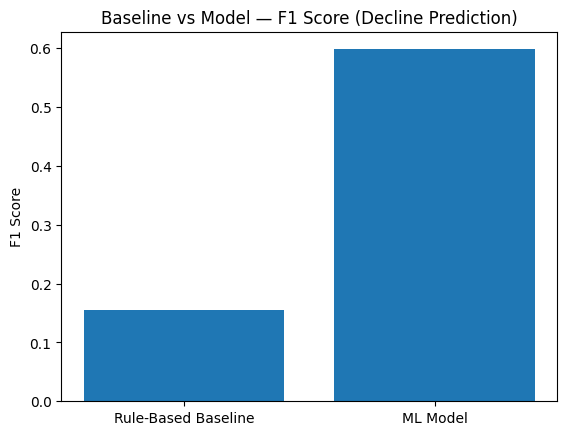

Baseline F1: 0.154, Model F1: 0.598


In [26]:
import matplotlib.pyplot as plt

baseline_preds = (features_df.loc[X_test.index, 'status'] == 'declining').astype(int)
from sklearn.metrics import f1_score

model_f1 = f1_score(y_test, preds)
baseline_f1 = f1_score(y_test, baseline_preds)

plt.bar(['Rule-Based Baseline', 'ML Model'], [baseline_f1, model_f1])
plt.title('Baseline vs Model — F1 Score (Decline Prediction)')
plt.ylabel('F1 Score')
plt.savefig('model_vs_baseline.png')
plt.show()

print(f"Baseline F1: {baseline_f1:.3f}, Model F1: {model_f1:.3f}")

In [27]:
final_output = features_df[[
    'content_hash_id', 'status', 'action', 'clicks_delta_pct',
    'position_delta', 'ctr_b', 'search_volume', 'main_intent'
]].sort_values('clicks_delta_pct')

final_output.to_csv('ranked_action_engine.csv', index=False)
final_output.head(20)

,content_hash_id,status,action,clicks_delta_pct,position_delta,ctr_b,search_volume,main_intent
42822,content_39c999d444484338,declining,rewrite,-1.0,-8.400000,0.0,20,informational
42676,content_e30b53ceb287d9bf,declining,rewrite,-1.0,-2.620109,0.0,10,commercial
42781,content_f725382741b3460d,declining,rewrite,-1.0,-2.154872,0.0,110,informational
42779,content_1f45a5be322a3492,volatile,review,-1.0,0.000000,0.0,0,informational
42795,content_0460333152a0c429,declining,rewrite,-1.0,-36.758741,0.0,70,informational
42804,content_1339ce1653f96e48,declining,rewrite,-1.0,-9.344130,0.0,170,informational
2854,content_98777940e08b9088,volatile,review,-1.0,17.152014,0.0,70,commercial
42830,content_824dff8bfeae0de4,volatile,review,-1.0,3.451724,0.0,40,informational
42826,content_59ba06ed48fc7477,declining,rewrite,-1.0,-3.684513,0.0,50,informational
42590,content_7a05035512af9553,volatile,review,-1.0,12.136364,0.0,0,informational


In [28]:
# 1. Kitne pages har category mein hain?
print(features_df['status'].value_counts())
print(features_df['status'].value_counts(normalize=True) * 100)  # percentage

status
stagnant      88025
volatile      29217
growing       15444
recovering     9466
declining      4499
Name: count, dtype: int64
status
stagnant      60.023457
volatile      19.922810
growing       10.531125
recovering     6.454780
declining      3.067828
Name: proportion, dtype: float64


In [29]:
# 2. Model ka F1 score kya aaya?
print(f"Baseline F1: {baseline_f1:.3f}")
print(f"Model F1: {model_f1:.3f}")

Baseline F1: 0.154
Model F1: 0.598


             feature  importance
2              ctr_b    0.778563
6         word_count    0.110201
1     position_delta    0.044142
0   clicks_delta_pct    0.037342
5  competition_level    0.017623
3              ctr_a    0.008887
4      search_volume    0.003242


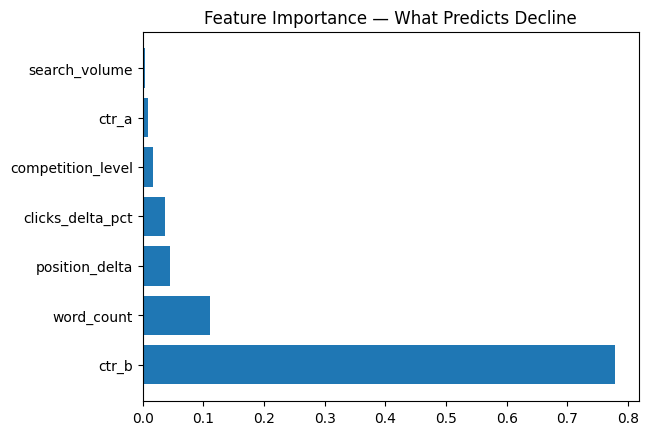

In [30]:
import pandas as pd

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('Feature Importance — What Predicts Decline')
plt.savefig('feature_importance.png')
plt.show()

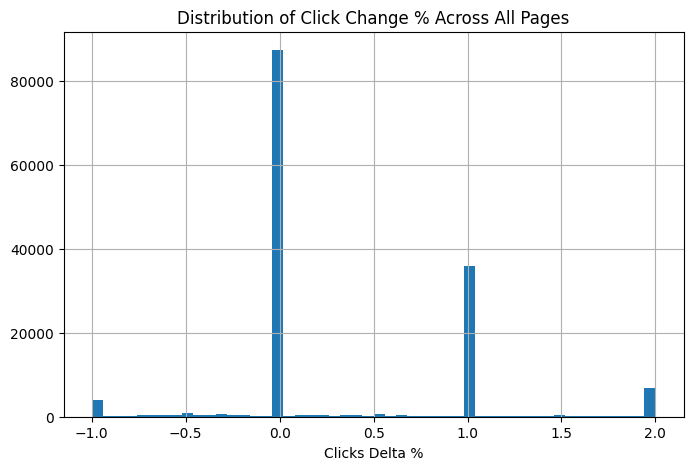

In [31]:
plt.figure(figsize=(8,5))
features_df['clicks_delta_pct'].clip(-1, 2).hist(bins=50)
plt.title('Distribution of Click Change % Across All Pages')
plt.xlabel('Clicks Delta %')
plt.savefig('clicks_delta_distribution.png')
plt.show()

In [32]:
print("=== TOP GROWING PAGES (Protect) ===")
print(features_df[features_df['status']=='growing'].nlargest(5, 'clicks_delta_pct')[['content_hash_id','clicks_delta_pct','position_delta']])

print("\n=== TOP DECLINING PAGES (Rewrite Priority) ===")
print(features_df[features_df['status']=='declining'].nsmallest(5, 'clicks_delta_pct')[['content_hash_id','clicks_delta_pct','position_delta']])

=== TOP GROWING PAGES (Protect) ===
                content_hash_id  clicks_delta_pct  position_delta
56145  content_18347c2069147531             290.0        0.330970
80970  content_3ea46fcd6bb8a9ef             257.0        3.955103
47204  content_f16ee5979097c419             188.0        5.379561
69744  content_78015c18938ad6ff             185.0        0.047147
77383  content_8f9d4ed5b17742be             165.0        1.883975

=== TOP DECLINING PAGES (Rewrite Priority) ===
             content_hash_id  clicks_delta_pct  position_delta
0   content_cd36f906cac66324              -1.0      -25.669007
19  content_909b80bd2d201504              -1.0       -0.389002
47  content_22b30c1a9a22e670              -1.0       -0.934514
50  content_fdbce2783ad6c5f9              -1.0       -6.475014
65  content_c608adb6e66f230b              -1.0      -19.707032
